# Music recommendation based on genre, mode, tempo using ML pipeline, evaluation and Hyperparameter tuning

### Prepared by: Udita Bose <uditab@student.unimelb.edu.au>

In [1]:

# import numpy, pandas, graphs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# import scikit libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    validation_curve,
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest
)

from sklearn.pipeline import Pipeline


In [3]:
# import kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [4]:
# load the dataset in a Panda DataFrame
all_music_data_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vicsuperman/prediction-of-music-genre",
    "music_genre.csv"
)


### Initial Data Exploration

In [5]:
# first few rows
all_music_data_df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [6]:
# basic statistics
# all_music_data_df = all_music_data_df.drop(columns=["instance_id"])
all_music_data_df.head()
all_music_data_df.describe()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,valence
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,55888.396360,44.220420,0.306383,0.558241,2.212526e+05,0.599755,0.181601,0.193896,-9.133761,0.093586,0.456264
std,20725.256253,15.542008,0.341340,0.178632,1.286720e+05,0.264559,0.325409,0.161637,6.162990,0.101373,0.247119
min,20002.000000,0.000000,0.000000,0.059600,-1.000000e+00,0.000792,0.000000,0.009670,-47.046000,0.022300,0.000000
25%,37973.500000,34.000000,0.020000,0.442000,1.748000e+05,0.433000,0.000000,0.096900,-10.860000,0.036100,0.257000
50%,55913.500000,45.000000,0.144000,0.568000,2.192810e+05,0.643000,0.000158,0.126000,-7.276500,0.048900,0.448000
75%,73863.250000,56.000000,0.552000,0.687000,2.686122e+05,0.815000,0.155000,0.244000,-5.173000,0.098525,0.648000
max,91759.000000,99.000000,0.996000,0.986000,4.830606e+06,0.999000,0.996000,1.000000,3.744000,0.942000,0.992000


In [7]:
# correlations existing in the raw data
all_correlation = all_music_data_df.corr(method="pearson", numeric_only=True)
print(f"Correlation of all data: \n{all_correlation}")

Correlation of all data: 
                  instance_id  popularity  acousticness  danceability  \
instance_id          1.000000    0.006317     -0.005268      0.000372   
popularity           0.006317    1.000000     -0.290453      0.356420   
acousticness        -0.005268   -0.290453      1.000000     -0.347681   
danceability         0.000372    0.356420     -0.347681      1.000000   
duration_ms         -0.005848   -0.083809      0.061862     -0.155507   
energy               0.009952    0.216345     -0.791250      0.263934   
instrumentalness    -0.004015   -0.364960      0.387970     -0.301277   
liveness             0.004737   -0.039468     -0.109220     -0.051465   
loudness             0.006847    0.317941     -0.730401      0.390859   
speechiness         -0.005908    0.224309     -0.163377      0.279767   
valence              0.005385    0.124913     -0.270238      0.434557   

                  duration_ms    energy  instrumentalness  liveness  loudness  \
instance_id     

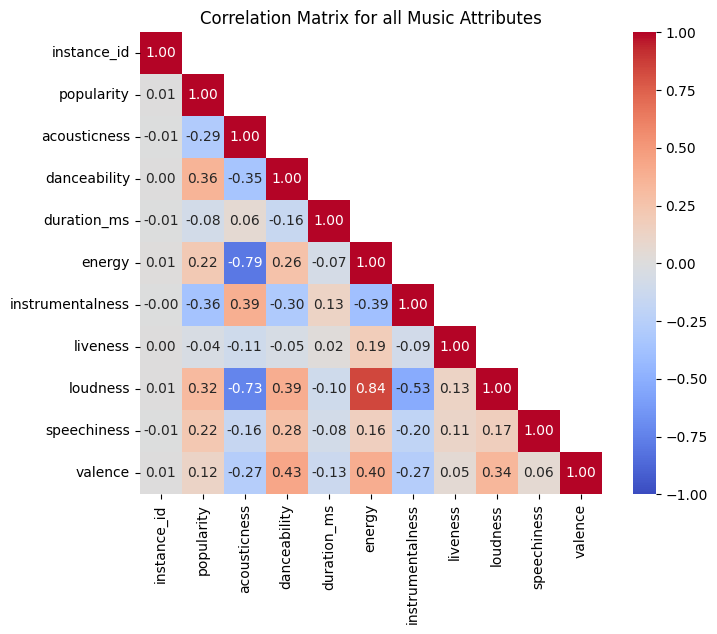

In [8]:
# correlation plotted
mask = np.triu(np.ones_like(all_correlation, dtype=float), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(all_correlation, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix for all Music Attributes")
plt.show()

In [9]:
# data shape
all_music_data_df.shape

(50005, 18)

In [10]:
# columns, and data types
all_music_data_df.dtypes

instance_id         float64
artist_name             str
track_name              str
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                     str
liveness            float64
loudness            float64
mode                    str
speechiness         float64
tempo                   str
obtained_date           str
valence             float64
music_genre             str
dtype: object

In [11]:
# raw data per genre
all_music_data_df['music_genre'].value_counts()

music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64

In [12]:
# unavailable data per feature
all_music_data_df.isna().sum()

instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

In [13]:
# unavailable data per feature
all_music_data_df['danceability'].value_counts()

danceability
0.5290    143
0.6570    139
0.6100    134
0.5540    133
0.4990    130
         ... 
0.0792      1
0.0832      1
0.0708      1
0.9860      1
0.9740      1
Name: count, Length: 1088, dtype: int64

In [14]:
# unique data for string columns
columns = ['key','mode','tempo']
for column in columns:
    print(f"    {column}: {all_music_data_df[column].unique()}")
    print()

    key: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str

    mode: <StringArray>
['Minor', 'Major', nan]
Length: 3, dtype: str

    tempo: <StringArray>
[           '100.889', '115.00200000000001',            '127.994',
            '128.014',            '145.036',                  '?',
            '149.995',            '120.008', '149.94799999999998',
            '139.933',
 ...
            '175.903',             '93.758',             '83.881',
            '128.194',            '138.964',            '129.939',
            '129.285',             '112.97',            '167.655',
  '99.20100000000001']
Length: 29395, dtype: str



In [15]:
# find any duplicated data
duplicated = all_music_data_df.duplicated()
print(f"duplicated : {all_music_data_df[duplicated]}")

duplicated :        instance_id artist_name track_name  popularity  acousticness  \
10001          NaN         NaN        NaN         NaN           NaN   
10002          NaN         NaN        NaN         NaN           NaN   
10003          NaN         NaN        NaN         NaN           NaN   
10004          NaN         NaN        NaN         NaN           NaN   

       danceability  duration_ms  energy  instrumentalness  key  liveness  \
10001           NaN          NaN     NaN               NaN  NaN       NaN   
10002           NaN          NaN     NaN               NaN  NaN       NaN   
10003           NaN          NaN     NaN               NaN  NaN       NaN   
10004           NaN          NaN     NaN               NaN  NaN       NaN   

       loudness mode  speechiness tempo obtained_date  valence music_genre  
10001       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10002       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10003       Na

In [16]:
only_mode_music = all_music_data_df[['track_name', 'mode', 'music_genre', 'popularity']]
only_mode_music.head()

,track_name,mode,music_genre,popularity
0,Röyksopp's Night Out,Minor,Electronic,27.0
1,The Shining Path,Minor,Electronic,31.0
2,Hurricane,Major,Electronic,28.0
3,Nitro,Major,Electronic,34.0
4,Divide & Conquer,Major,Electronic,32.0


## Visualize data

/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_60160/205126863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each mode')

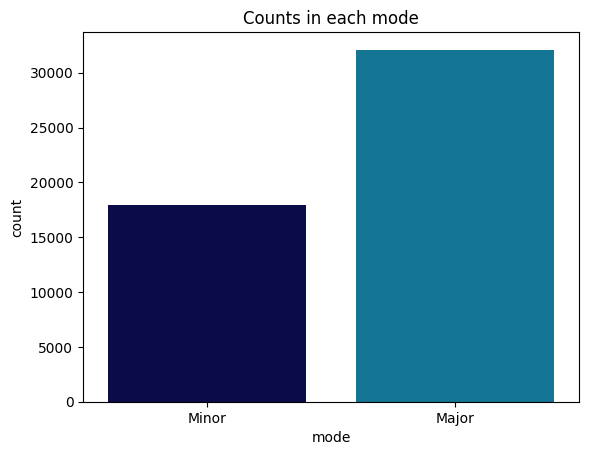

In [17]:
sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each mode")


All keys: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str



/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_60160/4043498728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each key')

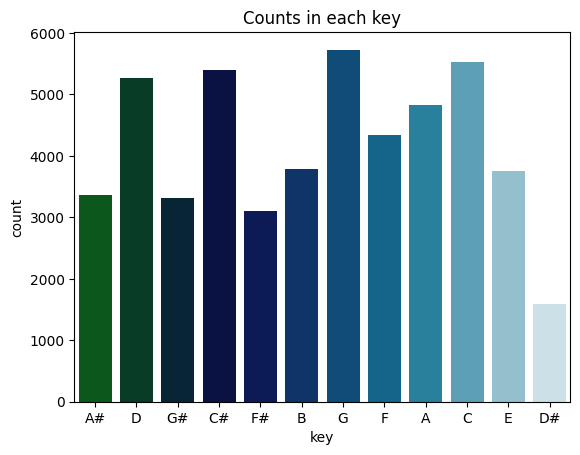

In [18]:
keys_of_music = all_music_data_df['key'].unique()
print(f"All keys: {keys_of_music}")
print()
sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each key")

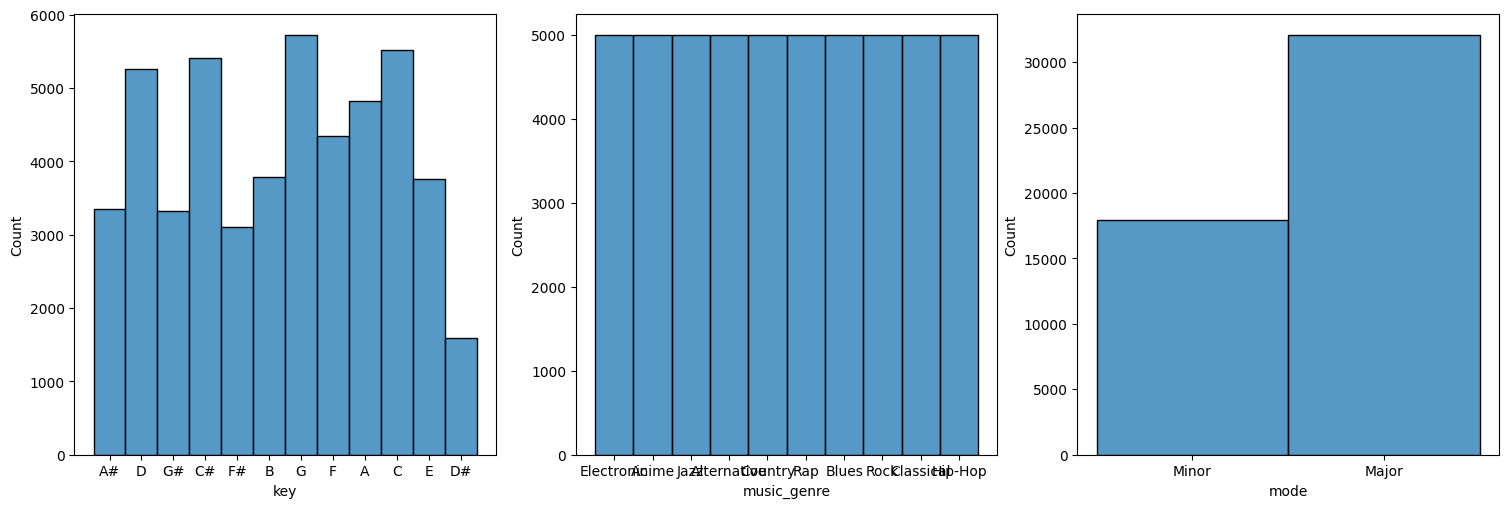

In [19]:
fig, axs = plt.subplots(ncols = 3, nrows = 1, figsize = (15, 5))
# fig.delaxes(axs[2][0])
index = 0

str_features = all_music_data_df[["key", "music_genre", "mode"]]

axs = axs.flatten()
for k, v in str_features.items():
    sns.histplot(v, ax = axs[index])
    index += 1
plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

In [19]:
# numeric_features = all_music_data_df.drop(["key", "music_genre", "mode"], axis = 1)
# fig, axs = plt.subplots(ncols = 3, nrows = 4, figsize = (15, 15))
# fig.delaxes(axs[3][2])
# index = 0
#
# axs = axs.flatten()
# for k, v in numeric_features.items():
#     if index < 12:
#         sns.histplot(v, ax = axs[index])
#         index += 1
# plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

## Preprocess Data

### Copy Data for future usages, and drop bad data

In [43]:
# copy the data
processed_df = all_music_data_df.copy()
print(f"Initial data shape: {processed_df.shape}")

Initial data shape: (50005, 18)


In [42]:
# remove the columns that won't be used for any prediction
processed_df = processed_df.drop(['instance_id', 'artist_name', 'track_name', 'obtained_date'], axis=1)
print(f"Data shape after dropping columns: {processed_df.shape}")

KeyError: "['instance_id', 'artist_name', 'track_name', 'obtained_date'] not found in axis"

In [44]:
# drop rows with bad values, Thanks to Zed
bad_values = ['', ' ', '?' , -1 , '-1']
rows_to_drop = processed_df.isna() | processed_df.isin(bad_values)
processed_df = processed_df[~rows_to_drop.any(axis=1)]
print(f"Data shape after dropping bad data: {processed_df.shape}")

Data shape after dropping bad data: (40560, 18)


In [45]:
# drop duplicated rows, from Zed
duplicate_rows = processed_df.duplicated()
if duplicate_rows.sum() > 0:
    print(f"Duplicate rows: \n{processed_df[duplicate_rows]}")
    processed_df = processed_df.drop_duplicates().reset_index(drop=True)

print(f"Data shape after dropping duplicated data: {processed_df.shape}")

Data shape after dropping duplicated data: (40560, 18)


The basic pre-processing of the data has deleted
- 4 columns
- 9446 rows

### Encode the non-numeric features

In [46]:
# save the cleaned data
processed_df.to_csv("./ub_music_genre_cleaned.csv")

In [47]:
# find the non-numeric columns
str_features = processed_df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Non-numeric features: {str_features}")

Non-numeric features: ['artist_name', 'track_name', 'key', 'mode', 'tempo', 'obtained_date', 'music_genre']


In [48]:
# encode all the non-numeric columns with LabelEncoder
encoder_list = []
encoded_df = processed_df.copy()
for sf in str_features:
    sf_encoder = LabelEncoder()
    encoded_df[sf] = sf_encoder.fit_transform(encoded_df[sf])
    encoder_list.append(sf_encoder)
    print(f"Label encoder for {sf}: {sf_encoder.classes_}")

Label encoder for artist_name: ['!!!' '"Weird Al" Yankovic' '$NOT' ... '楚神ウリエ(CV.近藤隆)' '鉤貫レム(CV.斉藤壮馬)'
 '黒崎真音']
Label encoder for track_name: ['"42" - From SR3MM' '"Blue Flame" (Interlude)' '"Boom"' ... '麗しき世界'
 '黒い弾丸' '黒い雫']
Label encoder for key: ['A' 'A#' 'B' 'C' 'C#' 'D' 'D#' 'E' 'F' 'F#' 'G' 'G#']
Label encoder for mode: ['Major' 'Minor']
Label encoder for tempo: ['100.0' '100.001' '100.00200000000001' ... '99.99700000000001'
 '99.99799999999999' '99.999']
Label encoder for obtained_date: ['1-Apr' '3-Apr' '4-Apr' '5-Apr']
Label encoder for music_genre: ['Alternative' 'Anime' 'Blues' 'Classical' 'Country' 'Electronic'
 'Hip-Hop' 'Jazz' 'Rap' 'Rock']


In [49]:
# print the shape of the data after encoding
print(f"Data shape after label encoding: {encoded_df.shape}")

Data shape after label encoding: (40560, 18)


In [50]:
# see the encoded data
encoded_df.describe()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
count,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,4.056000e+04,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000
mean,55874.826430,3327.289103,17231.600296,44.276677,0.305974,0.558418,2.454895e+05,0.600330,0.181603,5.346672,0.193820,-9.126369,0.359985,0.093738,13404.254315,1.918910,0.456921,4.505843
std,20731.018576,1914.425149,9947.161077,15.545617,0.341108,0.178652,1.101214e+05,0.264501,0.325710,3.461049,0.161501,6.154679,0.480002,0.101502,7990.532894,0.349147,0.246942,2.875219
min,20002.000000,0.000000,0.000000,0.000000,0.000000,0.059600,1.550900e+04,0.000792,0.000000,0.000000,0.009670,-47.046000,0.000000,0.022300,0.000000,0.000000,0.000000,0.000000
25%,37994.750000,1717.000000,8650.750000,34.000000,0.020000,0.442000,1.904800e+05,0.433000,0.000000,3.000000,0.097000,-10.843000,0.000000,0.036100,6579.000000,2.000000,0.259000,2.000000
50%,55899.500000,3290.000000,17188.500000,45.000000,0.144000,0.569000,2.275330e+05,0.644000,0.000157,5.000000,0.126000,-7.277000,0.000000,0.048900,12848.500000,2.000000,0.449000,5.000000
75%,73817.500000,5019.000000,25808.250000,56.000000,0.550000,0.687000,2.757600e+05,0.817000,0.152000,8.000000,0.244000,-5.174000,1.000000,0.098800,20613.250000,2.000000,0.648000,7.000000
max,91759.000000,6362.000000,34679.000000,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,11.000000,1.000000,3.744000,1.000000,0.942000,27287.000000,3.000000,0.992000,9.000000


### One-hot encode the data

In [51]:
# columns for one-hot encoding
oh_encoded_df = encoded_df.copy()
oh_encoded_df.drop('music_genre', axis=1)

numerical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes != object]
categorical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes == object]

# scaling numeric data via StandardScaler
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# encoding non-numerical (categorical) data via OneHotEncoding
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(drop='if_binary'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

oh_encoded_df = pd.DataFrame(preprocessor.fit_transform(oh_encoded_df))

print(f"Data sample after preprocessing: \n{oh_encoded_df.head()}")

Data sample after preprocessing: 
         0         1         2         3         4         5         6   \
0 -0.444886  1.215895  1.181397 -0.854057 -0.859781  0.355901 -0.246972   
1 -1.243458 -0.967033 -0.474372 -1.047040 -0.888042  0.344706 -0.271309   
2  0.304001 -0.910618  0.227847 -0.661074 -0.822549  1.206728 -0.713898   
3 -1.493810  1.412301 -1.008702 -0.789729 -0.883381  0.445462 -0.209957   
4 -0.584389 -0.280656 -1.191571  0.110857 -0.812288  0.076024 -0.282251   

         7         8         9         10        11        12        13  \
0  1.095173  2.359175 -0.100165 -0.432322  0.338506  1.333376 -0.627956   
1  0.584770 -0.521338  1.633435  2.106386  0.732682 -0.749976 -0.583621   
2  0.376829 -0.549799 -0.389098 -0.227987  0.752018 -0.749976  1.431139   
3 -0.050397  2.233294  1.055568 -0.227987  0.464753 -0.749976 -0.516627   
4  0.766247 -0.557543 -0.966965 -0.543778  0.785163 -0.749976  2.534577   

         14        15        16       17  
0 -1.188578  0.232254

In [52]:
print(f"Columns after preprocessing: \n{oh_encoded_df.columns}")

Columns after preprocessing: 
RangeIndex(start=0, stop=18, step=1)


In [53]:
print(f"Data shape after preprocessing: {oh_encoded_df.shape}")

Data shape after preprocessing: (40560, 18)


In [54]:
print(f"Basic statistics after preprocessing: \n{oh_encoded_df.describe()}")

Basic statistics after preprocessing: 
                 0             1             2             3             4   \
count  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04   
mean   1.156209e-17  5.886153e-17 -1.401465e-17 -1.569641e-16 -6.727032e-17   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -1.730415e+00 -1.738031e+00 -1.732335e+00 -2.848213e+00 -8.970130e-01   
25%   -8.624900e-01 -8.411449e-01 -8.626538e-01 -6.610740e-01 -8.383797e-01   
50%    1.190191e-03 -1.947820e-02 -4.332978e-03  4.652967e-02 -4.748535e-01   
75%    8.655096e-01  8.836761e-01  8.622315e-01  7.541334e-01  7.154017e-01   
max    1.730963e+00  1.585201e+00  1.754030e+00  3.520221e+00  2.022923e+00   

                 5             6             7             8             9   \
count  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04   
mean   3.013150e-16 -1.149201e-16 -1.009055e-16  3.363516e-17 -8.689083e-17   
std    1.000

### Combined encoding for final processing output

In [55]:
# One-hot encoding for key, and mode
processed_df = pd.get_dummies(processed_df, columns=['key'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['mode'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['music_genre'], drop_first=True)

print(f"Data shape after one-hot encoding: \n{processed_df.shape}")
print(f"Data sample after one-hot encoding: \n{processed_df.head(10)}")

Data shape after one-hot encoding: 
(40560, 36)
Data sample after one-hot encoding: 
    instance_id           artist_name                   track_name  \
1       46652.0  Thievery Corporation             The Shining Path   
2       30097.0        Dillon Francis                    Hurricane   
3       62177.0              Dubloadz                        Nitro   
4       24907.0           What So Not             Divide & Conquer   
6       43760.0        Jordan Comolli                        Clash   
7       30738.0                Hraach                      Delirio   
8       84950.0                 Kayzo                  NEVER ALONE   
9       56950.0                Shlump                   Lazer Beam   
10      49030.0        Chase & Status  Lost & Not Found - Acoustic   
11      22654.0               G Jones                         Mind   

    popularity  acousticness  danceability  duration_ms  energy  \
1         31.0       0.01270         0.622     218293.0   0.890   
2         

In [56]:
print(f"Columns after one-hot encoding: \n{processed_df.columns}")

Columns after one-hot encoding: 
Index(['instance_id', 'artist_name', 'track_name', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'obtained_date', 'valence', 'key_A#', 'key_B', 'key_C', 'key_C#',
       'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#',
       'mode_Minor', 'music_genre_Anime', 'music_genre_Blues',
       'music_genre_Classical', 'music_genre_Country',
       'music_genre_Electronic', 'music_genre_Hip-Hop', 'music_genre_Jazz',
       'music_genre_Rap', 'music_genre_Rock'],
      dtype='str')


After one-hot encoding, we have 18 more columns

In [57]:
# convert tempo to numeric
processed_df['tempo'] = processed_df['tempo'].astype(float, errors = 'ignore')
print(f"Tempo data after one-hot encoding: \n{processed_df['tempo'].head(10)}")

Tempo data after one-hot encoding: 
1     115.002
2     127.994
3     128.014
4     145.036
6     149.995
7     120.008
8     149.948
9     139.933
10     57.528
11    178.543
Name: tempo, dtype: float64


In [58]:
# tempo statistics
# tempo_bins = [0, 20, 40, 60, 100]
# labels = ['0-20', '21-40', '41-60', '61+']
# processed_df['tempo'] = processed_df['tempo'].astype(float, errors = 'ignore')
# print(f"Tempo data after one-hot encoding: \n{processed_df['tempo'].head(10)}")

count    40560.000000
mean       119.874523
std         30.653215
min         34.347000
25%         94.893000
50%        119.755500
75%        140.344000
max        220.276000
Name: tempo, dtype: float64

In [61]:
# bin tempo
tempo_bins = [30, 95, 120, 140, 200]
tempo_labels = ['Low', 'Comfortable', 'High', 'Piercing']
processed_df['tempo_group'] = pd.cut(
    processed_df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
print(f"Tempo data after one-hot encoding: \n{processed_df['tempo_group'].head(10)}")

Tempo data after one-hot encoding: 
1     Comfortable
2            High
3            High
4        Piercing
6        Piercing
7            High
8        Piercing
9            High
10            Low
11       Piercing
Name: tempo_group, dtype: category
Categories (4, str): ['Low' < 'Comfortable' < 'High' < 'Piercing']


In [64]:
# more view into tempo groups
processed_df['tempo_group'].value_counts()

tempo_group
Piercing       10490
Comfortable    10404
Low            10306
High            9157
Name: count, dtype: int64

In [40]:
# Scalar transform all numeric data
# numerical_cols = processed_df.columns[processed_df.dtypes != object]
# num_scaler = StandardScaler()
# processed_df = pd.DataFrame(num_scaler.fit_transform(processed_df))
#
# print(f"Data shape after scaling numeric: \n{processed_df.shape}")
# print(f"Data sample after scaling numeric: \n{processed_df.head(10)}")

In [65]:
# save the final pre-processed data in a separate CSV
processed_df.to_csv("./ub_music_genre_cleaned_preprepped_v2.csv")

## Model, and fitting data

### Models for use

In [66]:
# Define models for use
# _TARGET = "popularity"
_TARGET = "tempo_group"
_NN_count = 5
_RANDOM_STATE = 42

model_map = {
    "Nearest Neighbors": KNeighborsClassifier(_NN_count),  # KNN with 5 neighbours
    "Linear SVM": SVC(kernel="linear", C=0.025, random_state=_RANDOM_STATE),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=_NN_count, random_state=_RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        max_depth=_NN_count, n_estimators=10, max_features=1, random_state=_RANDOM_STATE
    ),  # ensemble method
    "Neural Net":  MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE),  # neural net
}

In [49]:
# split the dataset in 80% train, 20% test
# following the naming convention for data for model
##  y = target label
##  X = feature labels
# print(processed_df.columns)
y = processed_df[_TARGET]
X = processed_df.drop(_TARGET, axis=1)

# split data to test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=_RANDOM_STATE
)

print(f"Test data shape: {X_test.shape} : \n{X_test.head()}")
print("-----------------------------------------------------")
print(f"Train data shape: {X_train.shape} : \n{X_train.head()}")

Test data shape: (8112, 31) : 
       popularity  acousticness  danceability  duration_ms  energy  \
216          46.0       0.87200         0.619     228867.0   0.564   
14886        49.0       0.08230         0.647     299627.0   0.669   
14399        57.0       0.00113         0.554     200520.0   0.843   
35844        35.0       0.00224         0.531     239200.0   0.982   
33692        36.0       0.92200         0.125     228000.0   0.230   

       instrumentalness  liveness  speechiness    tempo  valence  ...  \
216            0.926000     0.160       0.0293  131.908   0.7870  ...   
14886          0.000000     0.342       0.2820   96.269   0.5530  ...   
14399          0.047600     0.165       0.0489  139.923   0.4420  ...   
35844          0.000072     0.409       0.0522  110.038   0.6010  ...   
33692          0.859000     0.078       0.0359   73.879   0.0392  ...   

       mode_Minor  music_genre_Anime  music_genre_Blues  \
216          True              False              

In [40]:
#X.iloc[:, 0].max()
# x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
# y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

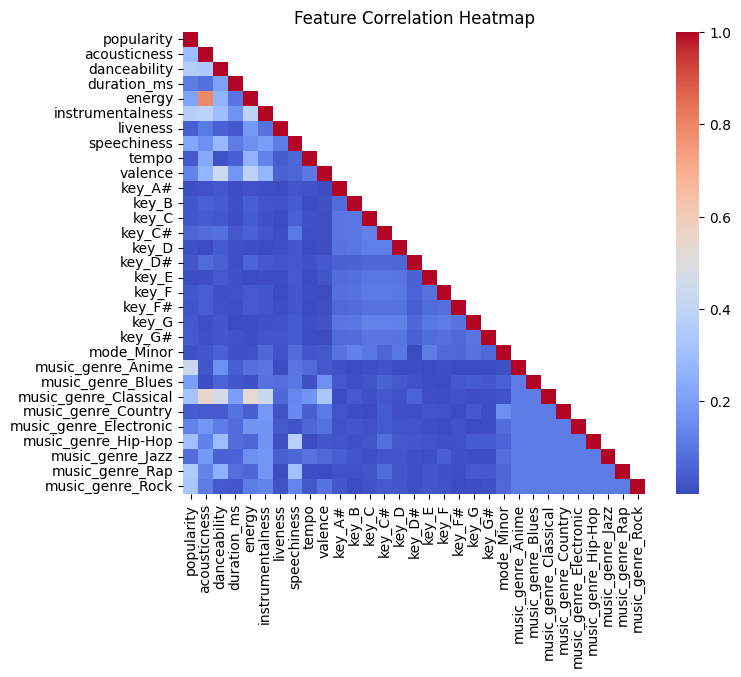

In [50]:
# Correlation matrix to explore target, from Pumi
feature_corr_matrix = X.corr().abs()

mask = np.triu(np.ones_like(feature_corr_matrix, dtype=float), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(feature_corr_matrix, mask=mask, cmap='coolwarm', annot=False, square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [51]:
# Mutual info
mutual_info_all = mutual_info_classif(X_train, y_train)
mutual_info_all = pd.Series(mutual_info_all)
mutual_info_all.index = X_train.columns
mutual_info_all.sort_values(ascending=False, inplace=True)

print(f"Mutual info about train data: {mutual_info_all}")

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [47]:
# Mutual info


Mutual info about train data: music_genre_Anime         0.148032
loudness                  0.127929
instrumentalness          0.118787
energy                    0.111743
danceability              0.107249
acousticness              0.104312
music_genre_Rap           0.094443
music_genre_Rock          0.084787
music_genre_Hip-Hop       0.081881
duration_ms               0.081681
music_genre_Classical     0.072612
speechiness               0.068553
valence                   0.057502
music_genre_Blues         0.055640
tempo                     0.041540
music_genre_Country       0.041488
music_genre_Jazz          0.040648
music_genre_Electronic    0.028795
liveness                  0.025456
key_C                     0.010444
key_A#                    0.010409
key_D#                    0.005748
key_C#                    0.002658
key_F                     0.001112
mode_Minor                0.000000
key_G#                    0.000000
key_F#                    0.000000
key_E                    

In [ ]:
# fit models, and plot
## inspiration: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html
# from matplotlib.colors import ListedColormap
# from sklearn.inspection import DecisionBoundaryDisplay
#
# figure = plt.figure(figsize=(15, 10))
# cm = plt.cm.RdBu
# cm_bright = ListedColormap(["#FF0000", "#0000FF"])
#
# x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
# y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
#
# i = 0  # counter for the subplot
# for model in model_map.keys():
#     clf = model_map[model]  # pick the model
#     clf.fit(X_train, y_train) # fit the training data
#     score = clf.score(X_test, y_test) # score the fit
#
#     ax = plt.subplot(len(model_map), len(model_map) + 1, i)  # subplot axis
#     DecisionBoundaryDisplay.from_estimator(
#         clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
#     )
#
#     # Plot the training points
#     ax.scatter(
#         X_train[:, 0],
#         X_train[:, 1],
#         c=y_train,
#         cmap=cm_bright,
#         edgecolors="k"
#     )
#     # Plot the testing points
#     ax.scatter(
#         X_test[:, 0],
#         X_test[:, 1],
#         c=y_test,
#         cmap=cm_bright,
#         edgecolors="k",
#         alpha=0.6,
#     )
#
#     ax.set_xlim(x_min, x_max)
#     ax.set_ylim(y_min, y_max)
#     ax.set_xticks(())
#     ax.set_yticks(())
#     ax.set_title(model)
#     ax.text(
#         x_max - 0.3,
#         y_min + 0.3,
#         ("%.2f" % score).lstrip("0"),
#         size=15,
#         horizontalalignment="right",
#     )
#
#     i = i + 1
#
# plt.tight_layout()
# plt.show()
